## Question 2.2

In [ ]:
import os

os.environ["KAGGLEHUB_CACHE"] = "/home/positive/aiops"
import kagglehub
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import idx2numpy as id
import numpy as np

# Download latest version
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

#loading dataset

x_train=id.convert_from_file(r'/home/positive/aiops/datasets/hojjatk/mnist-dataset/versions/1/train-images.idx3-ubyte')
y_train=id.convert_from_file(r'/home/positive/aiops/datasets/hojjatk/mnist-dataset/versions/1/train-labels.idx1-ubyte')
x_test=id.convert_from_file(r'/home/positive/aiops/datasets/hojjatk/mnist-dataset/versions/1/t10k-images.idx3-ubyte')
y_test=id.convert_from_file(r'/home/positive/aiops/datasets/hojjatk/mnist-dataset/versions/1/t10k-labels.idx1-ubyte')
x_train=x_train.reshape(-1,28*28).astype(np.float32)/255.0
x_test = x_test.reshape(-1, 28 * 28).astype(np.float32) / 255.0

#running experiment


import mlflow
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("mnist-classifier")
architecture=[(64,1),(64,32),(64,32,16)]


with mlflow.start_run(run_name='lr_arch_sweep') as parent:
    
    for lr in [0.01,0.001]:
        for arch in architecture:
            print(f'running the code with lr={lr} and architecture={arch}')
        
            with mlflow.start_run(run_name=f'lr-{lr},architecture-{arch}',nested=True):
                
                mlflow.log_param('lr',lr)
                mlflow.log_param('hidden layer ',str(arch))#syntax error, mlflow doesnt allow alphanumerics in log_param
                mlp=MLPClassifier(  hidden_layer_sizes=arch, 
                max_iter=100, 
                alpha=1e-4,
                solver='adam', 
                verbose=False, 
                learning_rate_init=lr,
                random_state=42)
                mlp.fit(x_train,y_train)
                train_pred=mlp.predict(x_train)
                train_acc=accuracy_score(y_train,train_pred)
                y_pred=mlp.predict(x_test)
                test_acc=accuracy_score(y_test,y_pred)
                for epoch,loss in enumerate(mlp.loss_curve_):
                    mlflow.log_metric(f'training loss',loss,step=epoch)#plot
                mlflow.log_metric('train accuracy',train_acc)
                mlflow.log_metric('accuracy',test_acc)


running the code with lr=0.01 and architecture=(64, 1)
🏃 View run lr-0.01,architecture-(64, 1) at: http://localhost:5000/#/experiments/2/runs/8eb6d295033244b0bc30608e40db752e
🧪 View experiment at: http://localhost:5000/#/experiments/2
running the code with lr=0.01 and architecture=(64, 32)
🏃 View run lr-0.01,architecture-(64, 32) at: http://localhost:5000/#/experiments/2/runs/b599ac0b09cc41a8b8e9c2ee601b2e06
🧪 View experiment at: http://localhost:5000/#/experiments/2
running the code with lr=0.01 and architecture=(64, 32, 16)
🏃 View run lr-0.01,architecture-(64, 32, 16) at: http://localhost:5000/#/experiments/2/runs/94d4c9486d4d4677ac763d50fcbfa702
🧪 View experiment at: http://localhost:5000/#/experiments/2
running the code with lr=0.001 and architecture=(64, 1)


/home/positive/aiops/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


🏃 View run lr-0.001,architecture-(64, 1) at: http://localhost:5000/#/experiments/2/runs/161e50ca88a140d3997b66c6769f330c
🧪 View experiment at: http://localhost:5000/#/experiments/2
running the code with lr=0.001 and architecture=(64, 32)
🏃 View run lr-0.001,architecture-(64, 32) at: http://localhost:5000/#/experiments/2/runs/16fdf6e13cb443a6b2adf8e1d76f31e6
🧪 View experiment at: http://localhost:5000/#/experiments/2
running the code with lr=0.001 and architecture=(64, 32, 16)
🏃 View run lr-0.001,architecture-(64, 32, 16) at: http://localhost:5000/#/experiments/2/runs/edfe61fcf2cf481186c9c67fa599f4a2
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run lr_arch_sweep at: http://localhost:5000/#/experiments/2/runs/9f92bb893f7c48f2b6b12169e087d6df
🧪 View experiment at: http://localhost:5000/#/experiments/2


## Question 2.1 Screenshot of experiments

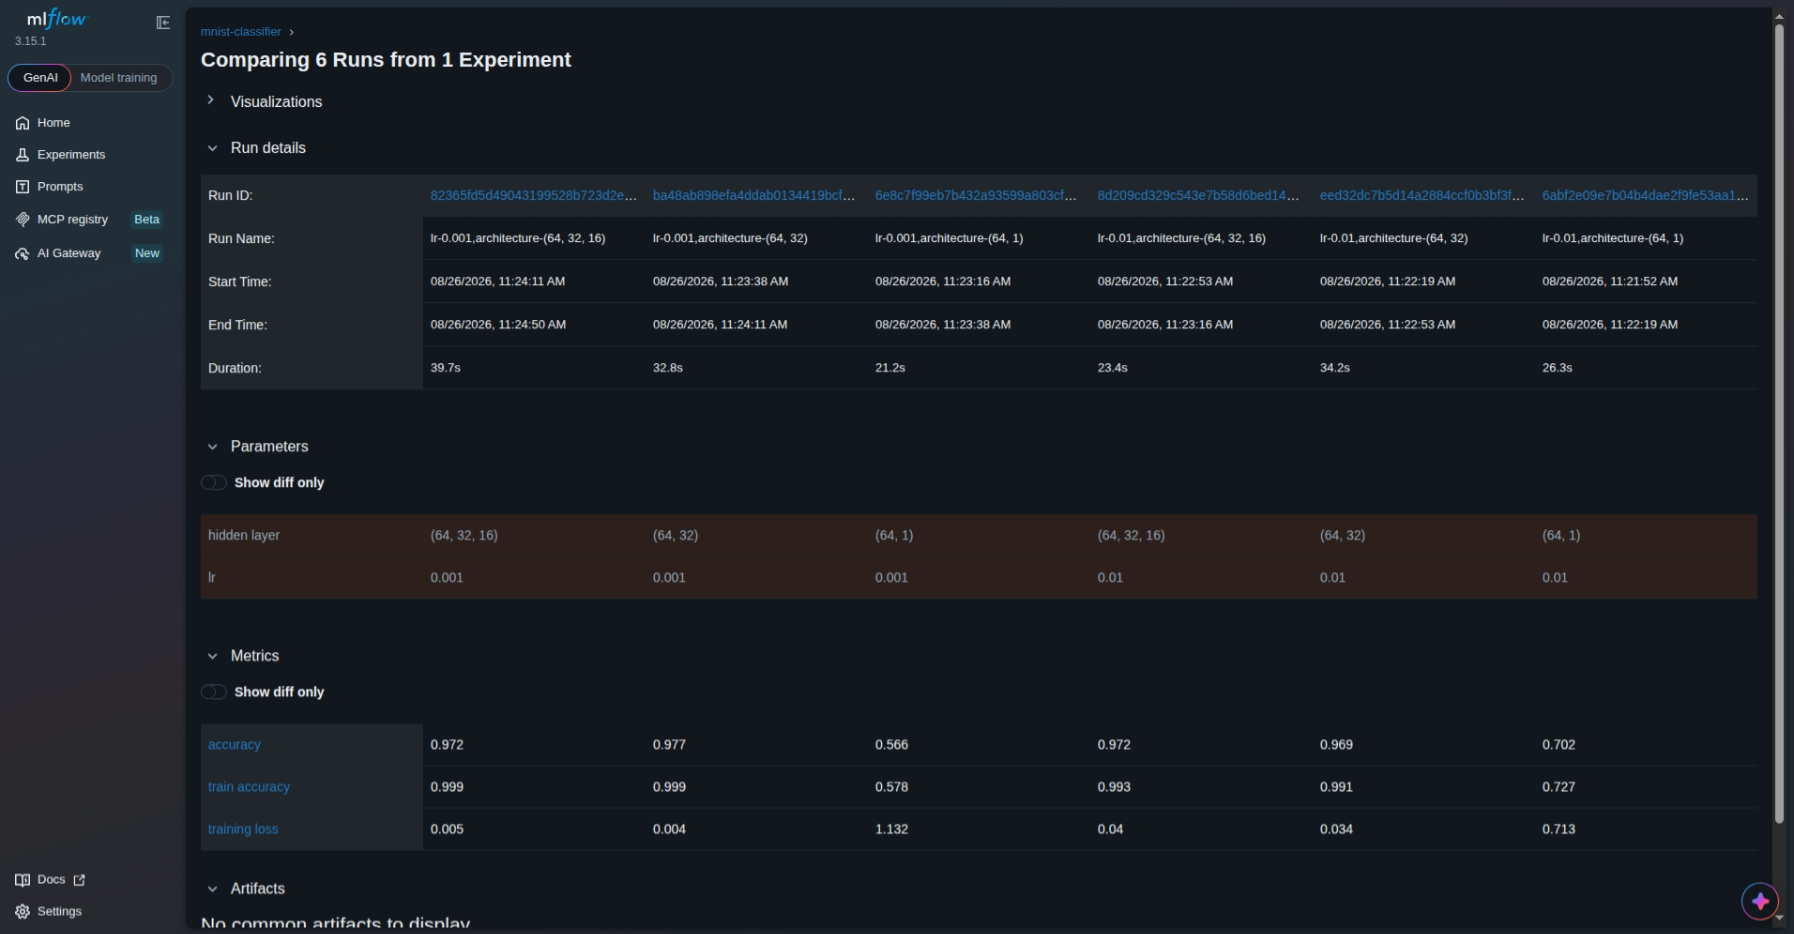

## Question 2.3:


I performed a small experiment sweep on the MNIST handwritten digit dataset using MLPClassifier. The aim was to compare how both the learning rate and the neural network architecture affect model performance. Three architectures were tested: (64, 1), (64, 32), and (64, 32, 16). Each architecture was trained with two learning rates, 0.01 and 0.001, resulting in a total of six runs. MLflow was used to record the parameters and metrics for each run.

The results show that the deeper architecture (64, 32, 16) performed well with both learning rates, achieving a test accuracy of approximately 0.972 in both cases. The (64, 32) architecture achieved the best overall test accuracy of 0.977 when trained with a learning rate of 0.001. However, reducing the learning rate to 0.01 decreased its test accuracy slightly to 0.969.

The smallest architecture, (64, 1), performed much worse than the other two. Its test accuracy was only 0.566 with a learning rate of 0.001 and 0.702 with 0.01. This suggests that this architecture did not have enough suitable hidden-layer capacity to learn the MNIST classification task effectively.

Overall, the experiment shows that both network architecture and learning rate significantly affect performance. The best result came from the (64, 32) architecture with a learning rate of 0.001. MLflow made it easier to compare all six runs by recording the parameters, training accuracy, test accuracy, and training loss for each experiment.